# Анализ лояльности пользователей Яндекс Афиши

## Этапы выполнения проекта

### 1. Загрузка данных и их предобработка

---

**Задача 1.1:** Напишите SQL-запрос, выгружающий в датафрейм pandas необходимые данные. Используйте следующие параметры для подключения к базе данных `data-analyst-afisha`:

- **Хост** — `rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net`
- **База данных** — `data-analyst-afisha`
- **Порт** — `6432`
- **Аутентификация** — `Database Native`
- **Пользователь** — `praktikum_student`
- **Пароль** — `Sdf4$2;d-d30pp`

Для выгрузки используйте запрос из предыдущего урока и библиотеку SQLAlchemy.

Выгрузка из базы данных SQL должна позволить собрать следующие данные:

- `user_id` — уникальный идентификатор пользователя, совершившего заказ;
- `device_type_canonical` — тип устройства, с которого был оформлен заказ (`mobile` — мобильные устройства, `desktop` — стационарные);
- `order_id` — уникальный идентификатор заказа;
- `order_dt` — дата создания заказа (используйте данные `created_dt_msk`);
- `order_ts` — дата и время создания заказа (используйте данные `created_ts_msk`);
- `currency_code` — валюта оплаты;
- `revenue` — выручка от заказа;
- `tickets_count` — количество купленных билетов;
- `days_since_prev` — количество дней от предыдущей покупки пользователя, для пользователей с одной покупкой — значение пропущено;
- `event_id` — уникальный идентификатор мероприятия;
- `service_name` — название билетного оператора;
- `event_type_main` — основной тип мероприятия (театральная постановка, концерт и так далее);
- `region_name` — название региона, в котором прошло мероприятие;
- `city_name` — название города, в котором прошло мероприятие.

---


In [1]:
# Используйте ячейки типа Code для вашего кода,
# а ячейки типа Markdown для комментариев и выводов

In [2]:
# При необходимости добавляйте новые ячейки для кода или текста

In [3]:
!pip install sqlalchemy 

In [4]:
!pip install psycopg2-binary

In [45]:
import pandas as pd
!pip install phik
import phik
import seaborn as sns
from sqlalchemy import create_engine
import matplotlib.pyplot as plt

In [6]:
db_config = {
    'user': 'praktikum_student',
    'pwd': 'Sdf4$2;d-d30pp',
    'host': 'rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net',
    'port': 6432,
    'db': 'data-analyst-afisha'
}

connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(
    db_config['user'],
    db_config['pwd'],
    db_config['host'],
    db_config['port'],
    db_config['db']
)

engine = create_engine(connection_string)

query = """
WITH set_config_precode AS (
    SELECT set_config('synchronize_seqscans', 'off', true)
)

SELECT
    p.user_id,
    p.device_type_canonical,
    p.order_id,
    p.created_dt_msk AS order_dt,
    p.created_ts_msk AS order_ts,
    p.currency_code,
    p.revenue,
    p.tickets_count,
    (
        p.created_dt_msk::date -
        LAG(p.created_dt_msk::date) OVER (
            PARTITION BY p.user_id
            ORDER BY p.created_dt_msk
        )
    ) AS days_since_prev,
    p.event_id,
    e.event_name_code AS event_name,
    p.service_name,
    e.event_type_main,
    r.region_name,
    c.city_name
FROM afisha.purchases AS p
JOIN afisha.events AS e
    ON p.event_id = e.event_id
JOIN afisha.city AS c
    ON e.city_id = c.city_id
JOIN afisha.regions AS r
    ON c.region_id = r.region_id
WHERE p.device_type_canonical IN ('mobile', 'desktop')
  AND e.event_type_main != 'фильм'
ORDER BY p.user_id;
"""
df = pd.read_sql_query(query, con=engine)

df.head(10)


,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,service_name,event_type_main,region_name,city_name
0,0002849b70a3ce2,mobile,4359165,2024-08-20,2024-08-20 16:08:03,rub,1521.94,4,NaN,169230,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,Край билетов,театр,Каменевский регион,Глиногорск
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23,2024-07-23 18:36:24,rub,289.45,2,NaN,237325,40efeb04-81b7-4135-b41f-708ff00cc64c,Мой билет,выставки,Каменевский регион,Глиногорск
2,0005ca5e93f2cf4,mobile,7292370,2024-10-06,2024-10-06 13:56:02,rub,1258.57,4,75.0,578454,01f3fb7b-ed07-4f94-b1d3-9a2e1ee5a8ca,За билетом!,другое,Каменевский регион,Глиногорск
3,000898990054619,mobile,1139875,2024-07-13,2024-07-13 19:40:48,rub,8.49,2,NaN,387271,2f638715-8844-466c-b43f-378a627c419f,Лови билет!,другое,Североярская область,Озёрск
4,000898990054619,mobile,972400,2024-10-04,2024-10-04 22:33:15,rub,1390.41,3,83.0,509453,10d805d3-9809-4d8a-834e-225b7d03f95d,Билеты без проблем,стендап,Озернинский край,Родниковецк
5,000898990054619,mobile,2613713,2024-10-23,2024-10-23 15:12:00,rub,902.74,3,19.0,500862,9cc55c15-4375-4129-9979-3129688ba1b4,Облачко,концерты,Лугоградская область,Кристалевск
6,00096d1f542ab2b,desktop,6636941,2024-08-15,2024-08-15 16:48:48,rub,917.83,4,NaN,201953,2f98d69f-4e60-4ffc-8f16-e539383526b1,Край билетов,театр,Каменевский регион,Глиногорск
7,000a55a418c128c,mobile,4657981,2024-09-29,2024-09-29 19:39:12,rub,47.78,1,NaN,265857,0d876e01-851e-458b-ba61-753e0e0c4063,Лучшие билеты,театр,Поленовский край,Дальнозолотск
8,000a55a418c128c,mobile,4657952,2024-10-15,2024-10-15 10:29:04,rub,74.84,2,16.0,271579,ddc795f8-7ef8-4eb0-b299-cb3e6ee24ba1,Лучшие билеты,театр,Поленовский край,Дальнозолотск
9,000cf0659a9f40f,mobile,6818017,2024-06-20,2024-06-20 10:35:26,rub,1421.91,4,NaN,516728,11be386f-7cb7-4aa1-a8e4-ba73a29c1af2,Лови билет!,концерты,Широковская область,Радужнополье


In [7]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  object        
 1   device_type_canonical  290611 non-null  object        
 2   order_id               290611 non-null  int64         
 3   order_dt               290611 non-null  datetime64[ns]
 4   order_ts               290611 non-null  datetime64[ns]
 5   currency_code          290611 non-null  object        
 6   revenue                290611 non-null  float64       
 7   tickets_count          290611 non-null  int64         
 8   days_since_prev        268678 non-null  float64       
 9   event_id               290611 non-null  int64         
 10  event_name             290611 non-null  object        
 11  service_name           290611 non-null  object        
 12  event_type_main        290611 non-null  obje

---

**Задача 1.2:** Изучите общую информацию о выгруженных данных. Оцените корректность выгрузки и объём полученных данных.

Предположите, какие шаги необходимо сделать на стадии предобработки данных — например, скорректировать типы данных.

Зафиксируйте основную информацию о данных в кратком промежуточном выводе.

---

В результате SQL- запроса был получен датафрейм размером 10 строк и 15 столбцов.
В датафрейме представлены следующие типы данных:
datetime64 - order_dt, order_ts;
float64 - revenue, days_since_prev;
int64 - order_id, tickets_count, event_id;
object - user_id, device_type_canonical, currency_code, event_name, service_name, event_type_main, region_name, city_name.

Большинство столбцов заполнены полностью. Только в days_since_prev есть пропуски, где заполнено 4 значения из 10. Это произошло скорее всего из-за того,что для пользователей с единственной покупкой предыдущей покупки нет, поэтому значение должно быть пропущенным.

На этапе предобработки можно выполнить следующие действия:
1.проверить наличие дубликатов заказов по order_id
2.проверить аномальные значения:отрицательную или нулевую выручку (revenue), некорректное количество билетов (tickets_count).

---

###  2. Предобработка данных

Выполните все стандартные действия по предобработке данных:

---

**Задача 2.1:** Данные о выручке сервиса представлены в российских рублях и казахстанских тенге. Приведите выручку к единой валюте — российскому рублю.

Для этого используйте датасет с информацией о курсе казахстанского тенге по отношению к российскому рублю за 2024 год — `final_tickets_tenge_df.csv`. Его можно загрузить по пути `https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')`

Значения в рублях представлено для 100 тенге.

Результаты преобразования сохраните в новый столбец `revenue_rub`.

---


In [8]:
tenge_rate = pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')

tenge_rate.head()
tenge_rate.info()

tenge_rate = pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')

tenge_rate['data'] = pd.to_datetime(tenge_rate['data'])
df['order_dt'] = pd.to_datetime(df['order_dt'])

df = df.merge(tenge_rate[['data', 'nominal', 'curs']], left_on='order_dt', right_on='data', how='left')

df['revenue_rub'] = df['revenue']

df.loc[df['currency_code'] == 'kzt', 'revenue_rub'] = (
    df['revenue'] * df['curs'] / df['nominal']
)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   data     357 non-null    object 
 1   nominal  357 non-null    int64  
 2   curs     357 non-null    float64
 3   cdx      357 non-null    object 
dtypes: float64(1), int64(1), object(2)
memory usage: 11.3+ KB


---

**Задача 2.2:**

- Проверьте данные на пропущенные значения. Если выгрузка из SQL была успешной, то пропуски должны быть только в столбце `days_since_prev`.
- Преобразуйте типы данных в некоторых столбцах, если это необходимо. Обратите внимание на данные с датой и временем, а также на числовые данные, размерность которых можно сократить.
- Изучите значения в ключевых столбцах. Обработайте ошибки, если обнаружите их.
    - Проверьте, какие категории указаны в столбцах с номинальными данными. Есть ли среди категорий такие, что обозначают пропуски в данных или отсутствие информации? Проведите нормализацию данных, если это необходимо.
    - Проверьте распределение численных данных и наличие в них выбросов. Для этого используйте статистические показатели, гистограммы распределения значений или диаграммы размаха.
        
        Важные показатели в рамках поставленной задачи — это выручка с заказа (`revenue_rub`) и количество билетов в заказе (`tickets_count`), поэтому в первую очередь проверьте данные в этих столбцах.
        
        Если обнаружите выбросы в поле `revenue_rub`, то отфильтруйте значения по 99 перцентилю.

После предобработки проверьте, были ли отфильтрованы данные. Если были, то оцените, в каком объёме. Сформулируйте промежуточный вывод, зафиксировав основные действия и описания новых столбцов.

---

In [9]:
df.isna().sum() #как и ожидалось пропуски только в days_since_prev

user_id                      0
device_type_canonical        0
order_id                     0
order_dt                     0
order_ts                     0
currency_code                0
revenue                      0
tickets_count                0
days_since_prev          21933
event_id                     0
event_name                   0
service_name                 0
event_type_main              0
region_name                  0
city_name                    0
data                         0
nominal                      0
curs                         0
revenue_rub                  0
dtype: int64

In [10]:
#уменьшаем типы числовых данных
df['tickets_count'] = df['tickets_count'].astype('int16')
df['event_id'] = df['event_id'].astype('int32')

df.info()



<class 'pandas.core.frame.DataFrame'>
Int64Index: 290611 entries, 0 to 290610
Data columns (total 19 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  object        
 1   device_type_canonical  290611 non-null  object        
 2   order_id               290611 non-null  int64         
 3   order_dt               290611 non-null  datetime64[ns]
 4   order_ts               290611 non-null  datetime64[ns]
 5   currency_code          290611 non-null  object        
 6   revenue                290611 non-null  float64       
 7   tickets_count          290611 non-null  int16         
 8   days_since_prev        268678 non-null  float64       
 9   event_id               290611 non-null  int32         
 10  event_name             290611 non-null  object        
 11  service_name           290611 non-null  object        
 12  event_type_main        290611 non-null  obje

In [11]:
df['device_type_canonical'].unique() #дубликатов найдено не было

array(['mobile', 'desktop'], dtype=object)

In [12]:
df['currency_code'].unique() #дубликатов найдено не было

array(['rub', 'kzt'], dtype=object)

In [13]:
df['event_type_main'].unique() #дубликатов найдено не было

array(['театр', 'выставки', 'другое', 'стендап', 'концерты', 'спорт',
       'ёлки'], dtype=object)

In [14]:
df[['revenue_rub','tickets_count']].describe()

,revenue_rub,tickets_count
count,290611.000000,290611.000000
mean,555.571987,2.754311
std,875.498172,1.170620
min,-90.760000,1.000000
25%,113.970000,2.000000
50%,351.140000,3.000000
75%,802.050000,4.000000
max,81174.540000,57.000000


In [15]:
df = df[df['revenue_rub'] >= 0]

quantil = df['revenue_rub'].quantile(0.99)
df = df[df['revenue_rub'] <= quantil]

df[['revenue_rub','tickets_count']].describe()

,revenue_rub,tickets_count
count,287405.000000,287405.000000
mean,518.719256,2.741323
std,511.951842,1.163087
min,0.000000,1.000000
25%,112.600000,2.000000
50%,344.830000,3.000000
75%,788.900000,3.000000
max,2628.421739,57.000000


In [16]:
len(df) 

287405

В ходе работы было удалено 11723 строки, также были устранены выбросы и отрицательная выручка. Дубликатов найдено не было, были уменьшаны типы числовых данных

---

### 3. Создание профиля пользователя

В будущем отдел маркетинга планирует создать модель для прогнозирования возврата пользователей. Поэтому сейчас они просят вас построить агрегированные признаки, описывающие поведение и профиль каждого пользователя.

---

**Задача 3.1.** Постройте профиль пользователя — для каждого пользователя найдите:

- дату первого и последнего заказа;
- устройство, с которого был сделан первый заказ;
- регион, в котором был сделан первый заказ;
- билетного партнёра, к которому обращались при первом заказе;
- жанр первого посещённого мероприятия (используйте поле `event_type_main`);
- общее количество заказов;
- средняя выручка с одного заказа в рублях;
- среднее количество билетов в заказе;
- среднее время между заказами.

После этого добавьте два бинарных признака:

- `is_two` — совершил ли пользователь 2 и более заказа;
- `is_five` — совершил ли пользователь 5 и более заказов.

**Рекомендация:** перед тем как строить профиль, отсортируйте данные по времени совершения заказа.

---


In [17]:
df = df.sort_values('order_ts')

user_profile = df.groupby('user_id').agg(
    first_order_dt=('order_dt','first'),
    last_order_dt=('order_dt','last'),
    first_device=('device_type_canonical','first'),
    first_region=('region_name','first'),
    first_service=('service_name','first'),
    first_event_type=('event_type_main','first'),
    orders_count=('order_id','count'),
    avg_revenue=('revenue_rub','mean'),
    avg_tickets=('tickets_count','mean'),
    avg_days_between=('days_since_prev','mean')
).reset_index()


user_profile['is_two'] = (user_profile['orders_count'] >= 2).astype(int)
user_profile['is_five'] = (user_profile['orders_count'] >= 5).astype(int)

user_profile.head()

,user_id,first_order_dt,last_order_dt,first_device,first_region,first_service,first_event_type,orders_count,avg_revenue,avg_tickets,avg_days_between,is_two,is_five
0,0002849b70a3ce2,2024-08-20,2024-08-20,mobile,Каменевский регион,Край билетов,театр,1,1521.940000,4.000000,NaN,0,0
1,0005ca5e93f2cf4,2024-07-23,2024-10-06,mobile,Каменевский регион,Мой билет,выставки,2,774.010000,3.000000,75.0,1,0
2,000898990054619,2024-07-13,2024-10-23,mobile,Североярская область,Лови билет!,другое,3,767.213333,2.666667,51.0,1,0
3,00096d1f542ab2b,2024-08-15,2024-08-15,desktop,Каменевский регион,Край билетов,театр,1,917.830000,4.000000,NaN,0,0
4,000a55a418c128c,2024-09-29,2024-10-15,mobile,Поленовский край,Лучшие билеты,театр,2,61.310000,1.500000,16.0,1,0


---

**Задача 3.2.** Прежде чем проводить исследовательский анализ данных и делать выводы, важно понять, с какими данными вы работаете: насколько они репрезентативны и нет ли в них аномалий.

Используя данные о профилях пользователей, рассчитайте:

- общее число пользователей в выборке;
- среднюю выручку с одного заказа;
- долю пользователей, совершивших 2 и более заказа;
- долю пользователей, совершивших 5 и более заказов.

Также изучите статистические показатели:

- по общему числу заказов;
- по среднему числу билетов в заказе;
- по среднему количеству дней между покупками.

По результатам оцените данные: достаточно ли их по объёму, есть ли аномальные значения в данных о количестве заказов и среднем количестве билетов?

Если вы найдёте аномальные значения, опишите их и примите обоснованное решение о том, как с ними поступить:

- Оставить и учитывать их при анализе?
- Отфильтровать данные по какому-то значению, например, по 95-му или 99-му перцентилю?

Если вы проведёте фильтрацию, то вычислите объём отфильтрованных данных и выведите статистические показатели по обновлённому датасету.

In [18]:
users_total = user_profile['user_id'].nunique()
users_total

21838

In [19]:
user_profile['avg_revenue'].mean()

545.0328001021667

In [20]:
user_profile['is_two'].mean()

0.6170436853191684

In [21]:
user_profile['is_five'].mean()

0.28995329242604634

In [22]:
user_profile['orders_count'].describe()

count    21838.000000
mean        13.160775
std        121.577370
min          1.000000
25%          1.000000
50%          2.000000
75%          5.000000
max      10168.000000
Name: orders_count, dtype: float64

In [23]:
user_profile['avg_tickets'].describe()

count    21838.000000
mean         2.744062
std          0.913083
min          1.000000
25%          2.000000
50%          2.750000
75%          3.080000
max         11.000000
Name: avg_tickets, dtype: float64

In [24]:
user_profile['avg_days_between'].describe()

count    13511.000000
mean        15.847068
std         22.304516
min          0.000000
25%          1.000000
50%          8.000000
75%         20.414286
max        148.000000
Name: avg_days_between, dtype: float64

In [25]:
quantile_orders = user_profile['orders_count'].quantile(0.96)
quantile_orders

user_profile_filtered = user_profile[user_profile['orders_count'] <= quantile_orders]

removed_count = len(user_profile) - len(user_profile_filtered)
removed_percent = (removed_count / len(user_profile)) * 100

print('Удалено пользователей:', removed_count)
print('Процент удалённых:', round(removed_percent, 2), "%")

Удалено пользователей: 856
Процент удалённых: 3.92 %


In [26]:
user_profile_filtered[['orders_count','avg_tickets','avg_days_between']].describe()

,orders_count,avg_tickets,avg_days_between
count,20982.000000,20982.000000,12655.000000
mean,4.409017,2.744812,16.803632
std,6.113950,0.930087,22.729598
min,1.000000,1.000000,0.000000
25%,1.000000,2.000000,1.000000
50%,2.000000,2.750000,9.062500
75%,5.000000,3.142857,21.800000
max,41.000000,11.000000,148.000000


Данных по объему достаточно. Аномальные значения в данных о количестве заказов был и их пришлось удалить. Среднее количество билетов в полне нормально, так что с ним ничего делать не надо. Я принял решение взять 95 процентиль, так как с 99 выбросы были все еще заметны, после этого на 8 изменилось среднее количсетво заказов, стандартное отклонение уменьшилось на 112. Такое решение было принято, так как выбросы сильно искажали данные и с ними нельзя будет работать дальше. Было удалено 862 строки, 4 процента от общего количества

---

### 4. Исследовательский анализ данных

Следующий этап — исследование признаков, влияющих на возврат пользователей, то есть на совершение повторного заказа. Для этого используйте профили пользователей.



#### 4.1. Исследование признаков первого заказа и их связи с возвращением на платформу

Исследуйте признаки, описывающие первый заказ пользователя, и выясните, влияют ли они на вероятность возвращения пользователя.

---

**Задача 4.1.1.** Изучите распределение пользователей по признакам.

- Сгруппируйте пользователей:
    - по типу их первого мероприятия;
    - по типу устройства, с которого совершена первая покупка;
    - по региону проведения мероприятия из первого заказа;
    - по билетному оператору, продавшему билеты на первый заказ.
- Подсчитайте общее количество пользователей в каждом сегменте и их долю в разрезе каждого признака. Сегмент — это группа пользователей, объединённых определённым признаком, то есть объединённые принадлежностью к категории. Например, все клиенты, сделавшие первый заказ с мобильного телефона, — это сегмент.
- Ответьте на вопрос: равномерно ли распределены пользователи по сегментам или есть выраженные «точки входа» — сегменты с наибольшим числом пользователей?

---


In [27]:
event_segment = user_profile.groupby('first_event_type')['user_id'].count().reset_index()

event_segment['share'] = event_segment['user_id'] / event_segment['user_id'].sum()

event_segment

,first_event_type,user_id,share
0,выставки,417,0.019095
1,другое,5465,0.250252
2,концерты,9647,0.441753
3,спорт,801,0.036679
4,стендап,1118,0.051195
5,театр,4295,0.196676
6,ёлки,95,0.004350


In [28]:
device_segment = user_profile.groupby('first_device')['user_id'].count().reset_index()

device_segment['share'] = device_segment['user_id'] / device_segment['user_id'].sum()

device_segment

,first_device,user_id,share
0,desktop,3748,0.171627
1,mobile,18090,0.828373


In [29]:
region_segment = user_profile.groupby('first_region')['user_id'].count().reset_index()

region_segment['share'] = region_segment['user_id'] / region_segment['user_id'].sum()

region_segment

,first_region,user_id,share
0,Белоярская область,20,0.000916
1,Берестовский округ,22,0.001007
2,Берёзовская область,115,0.005266
3,Боровлянский край,99,0.004533
4,Верховинская область,3,0.000137
...,...,...,...
76,Шанырский регион,505,0.023125
77,Широковская область,1236,0.056599
78,Яблоневская область,416,0.019049
79,Ягодиновская область,64,0.002931


In [30]:
service_segment = user_profile.groupby('first_service')['user_id'].count().reset_index()

service_segment['share'] = service_segment['user_id'] / service_segment['user_id'].sum()

service_segment

,first_service,user_id,share
0,Crazy ticket!,45,0.002061
1,Show_ticket,163,0.007464
2,Билет по телефону,6,0.000275
3,Билеты без проблем,5204,0.238300
4,Билеты в руки,2592,0.118692
5,Быстробилет,162,0.007418
6,Быстрый кассир,61,0.002793
7,Весь в билетах,1305,0.059758
8,Восьмёрка,86,0.003938
9,Вперёд!,7,0.000321


Пользователи распределены не равномерны, конценты - 9646, 44 процента.Широковская область - 1236,5 процентов.mobile -18090,82 процента.Билеты без проблем - 5204,0.23.

---

**Задача 4.1.2.** Проанализируйте возвраты пользователей:

- Для каждого сегмента вычислите долю пользователей, совершивших два и более заказа.
- Визуализируйте результат подходящим графиком. Если сегментов слишком много, то поместите на график только 10 сегментов с наибольшим количеством пользователей. Такое возможно с сегментами по региону и по билетному оператору.
- Ответьте на вопросы:
    - Какие сегменты пользователей чаще возвращаются на Яндекс Афишу?
    - Наблюдаются ли успешные «точки входа» — такие сегменты, в которых пользователи чаще совершают повторный заказ, чем в среднем по выборке?

При интерпретации результатов учитывайте размер сегментов: если в сегменте мало пользователей (например, десятки), то доли могут быть нестабильными и недостоверными, то есть показывать широкую вариацию значений.

---


In [31]:
avg_return = user_profile['is_two'].mean()
avg_return

0.6170436853191684

In [32]:
event_return = user_profile.groupby('first_event_type').agg(
    users=('user_id','count'),
    return_rate=('is_two','mean')
).reset_index()

event_return

,first_event_type,users,return_rate
0,выставки,417,0.645084
1,другое,5465,0.600366
2,концерты,9647,0.621437
3,спорт,801,0.561798
4,стендап,1118,0.611807
5,театр,4295,0.638650
6,ёлки,95,0.557895


<AxesSubplot:title={'center':'Доля возврата пользователей по типу первого мероприятия'}, xlabel='first_event_type'>

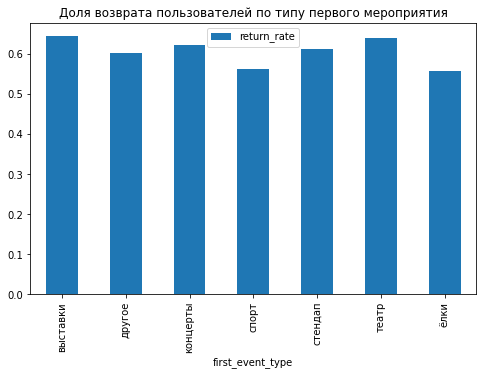

In [33]:
event_return.plot(
    x='first_event_type',
    y='return_rate',
    kind='bar',
    figsize=(8,5),
    title='Доля возврата пользователей по типу первого мероприятия'
)

In [34]:
device_return = user_profile.groupby('first_device').agg(
    users=('user_id','count'),
    return_rate=('is_two','mean')
).reset_index()

device_return

,first_device,users,return_rate
0,desktop,3748,0.641409
1,mobile,18090,0.611996


<AxesSubplot:title={'center':'Доля возврата по устройствам'}, xlabel='first_device'>

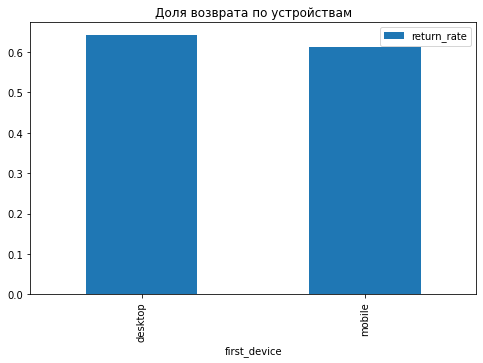

In [35]:
device_return.plot(
    x='first_device',
    y='return_rate',
    kind='bar',
    figsize=(8,5),
    title='Доля возврата по устройствам'
)

In [36]:
region_return = user_profile.groupby('first_region').agg(
    users=('user_id','count'),
    return_rate=('is_two','mean')
).reset_index()

region_top10 = region_return.sort_values('users', ascending=False).head(10)

region_top10

,first_region,users,return_rate
23,Каменевский регион,7160,0.627793
60,Североярская область,3800,0.641316
77,Широковская область,1236,0.648058
45,Озернинский край,678,0.554572
41,Малиновоярский округ,530,0.562264
76,Шанырский регион,505,0.675248
74,Травяная область,493,0.618661
57,Светополянский округ,464,0.661638
52,Речиновская область,446,0.639013
78,Яблоневская область,416,0.598558


In [37]:
service_return = user_profile.groupby('first_service').agg(
    users=('user_id','count'),
    return_rate=('is_two','mean')
).reset_index()

service_top10 = service_return.sort_values('users', ascending=False).head(10)

service_top10

,first_service,users,return_rate
3,Билеты без проблем,5204,0.606072
22,Мой билет,2993,0.611761
19,Лови билет!,2851,0.614872
4,Билеты в руки,2592,0.632716
23,Облачко,2194,0.615314
7,Весь в билетах,1305,0.634483
20,Лучшие билеты,1186,0.614671
24,Прачечная,588,0.629252
17,Край билетов,459,0.655773
12,Дом культуры,358,0.648045


<AxesSubplot:title={'center':'Возвраты по билетным операторам (топ 10)'}, xlabel='first_service'>

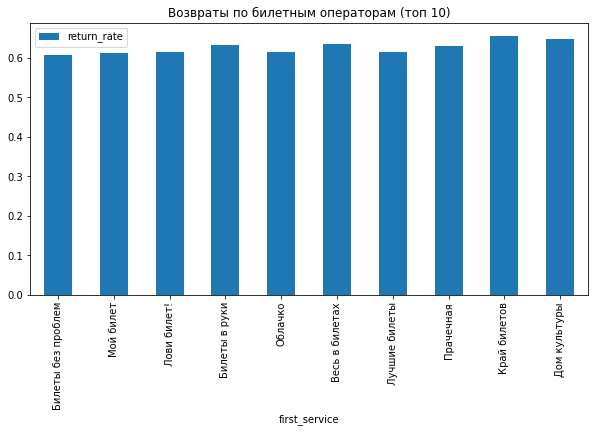

In [38]:
service_top10.plot(
    x='first_service',
    y='return_rate',
    kind='bar',
    figsize=(10,5),
    title='Возвраты по билетным операторам (топ 10)'
)

Чаще всего возвращаются концерты - 0.62 , теартры - 0.64 , выставки - 0.65. return_rate>avg_return тогда сегмент является успешным, то есть больше 0.62, это выставки, конценрты, театр

---

**Задача 4.1.3.** Опираясь на выводы из задач выше, проверьте продуктовые гипотезы:

- **Гипотеза 1.** Тип мероприятия влияет на вероятность возврата на Яндекс Афишу: пользователи, которые совершили первый заказ на спортивные мероприятия, совершают повторный заказ чаще, чем пользователи, оформившие свой первый заказ на концерты.
- **Гипотеза 2.** В регионах, где больше всего пользователей посещают мероприятия, выше доля повторных заказов, чем в менее активных регионах.

---

In [39]:
event_return = user_profile.groupby('first_event_type')['is_two'].mean()
event_return

first_event_type
выставки    0.645084
другое      0.600366
концерты    0.621437
спорт       0.561798
стендап     0.611807
театр       0.638650
ёлки        0.557895
Name: is_two, dtype: float64

In [40]:
sport_return = event_return['спорт']
concert_return = event_return['концерты']

print('Возврат после спорта:', sport_return)
print('Возврат после концертов:', concert_return)

Возврат после спорта: 0.5617977528089888
Возврат после концертов: 0.621436716077537


Гипотеза не верна, так как 0.56 меньше, чем 0.62

In [41]:
region_analysis = user_profile.groupby('first_region').agg(
    users=('user_id','count'),
    return_rate=('is_two','mean')
).reset_index()

region_analysis

,first_region,users,return_rate
0,Белоярская область,20,0.650000
1,Берестовский округ,22,0.636364
2,Берёзовская область,115,0.669565
3,Боровлянский край,99,0.515152
4,Верховинская область,3,0.666667
...,...,...,...
76,Шанырский регион,505,0.675248
77,Широковская область,1236,0.648058
78,Яблоневская область,416,0.598558
79,Ягодиновская область,64,0.671875


In [42]:
top_regions = region_analysis.sort_values('users', ascending=False).head(10)
top_regions

,first_region,users,return_rate
23,Каменевский регион,7160,0.627793
60,Североярская область,3800,0.641316
77,Широковская область,1236,0.648058
45,Озернинский край,678,0.554572
41,Малиновоярский округ,530,0.562264
76,Шанырский регион,505,0.675248
74,Травяная область,493,0.618661
57,Светополянский округ,464,0.661638
52,Речиновская область,446,0.639013
78,Яблоневская область,416,0.598558


In [43]:
small_regions = region_analysis.sort_values('users').head(10)
small_regions

,first_region,users,return_rate
80,Яснопольский округ,1,0.000000
66,Сосноводолинская область,1,0.000000
5,Верхозёрский край,1,1.000000
17,Залесский край,2,0.500000
56,Светолесский край,2,0.500000
70,Тихогорская область,2,0.500000
68,Теплоозёрский округ,3,0.333333
33,Лесноярский край,3,0.666667
32,Крутоводский регион,3,0.333333
4,Верховинская область,3,0.666667


Гипотеза 2 верна, так как если сложить все средние топ регионов 0.62+0.64+0.64+0.55+0.56+0.67+0.61+0.66+0.63+0.59=6,17 и маленьких 0+0+1+0.5+0.5+0.5+0.33+0.66+0.33+0.66=4,48

---

#### 4.2. Исследование поведения пользователей через показатели выручки и состава заказа

Изучите количественные характеристики заказов пользователей, чтобы узнать среднюю выручку сервиса с заказа и количество билетов, которое пользователи обычно покупают.

Эти метрики важны не только для оценки выручки, но и для оценки вовлечённости пользователей. Возможно, пользователи с более крупными и дорогими заказами более заинтересованы в сервисе и поэтому чаще возвращаются.

---

**Задача 4.2.1.** Проследите связь между средней выручкой сервиса с заказа и повторными заказами.

- Постройте сравнительные гистограммы распределения средней выручки с билета (`avg_revenue_rub`):
    - для пользователей, совершивших один заказ;
    - для вернувшихся пользователей, совершивших 2 и более заказа.
- Ответьте на вопросы:
    - В каких диапазонах средней выручки концентрируются пользователи из каждой группы?
    - Есть ли различия между группами?

Текст на сером фоне:
    
**Рекомендация:**

1. Используйте одинаковые интервалы (`bins`) и прозрачность (`alpha`), чтобы визуально сопоставить распределения.
2. Задайте параметру `density` значение `True`, чтобы сравнивать форму распределений, даже если число пользователей в группах отличается.

---


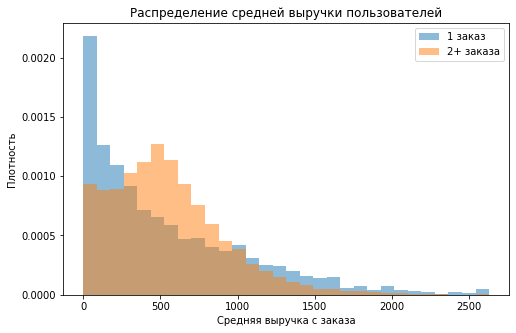

In [46]:
one_order = user_profile[user_profile['is_two'] == 0]
repeat_users = user_profile[user_profile['is_two'] == 1]

plt.figure(figsize=(8,5))

plt.hist(one_order['avg_revenue'], bins=30, alpha=0.5, density=True, label='1 заказ')
plt.hist(repeat_users['avg_revenue'], bins=30, alpha=0.5, density=True, label='2+ заказа')

plt.xlabel('Средняя выручка с заказа')
plt.ylabel('Плотность')
plt.title('Распределение средней выручки пользователей')
plt.legend()

plt.show()

Оснавная  концентрация пользовалетей с 1 заказом находится в диапазоне 0-300, после 300 кол-во пользователей резко уменьшается.Пользовалетели с 2+ заказами 300-800, больше пользователей со средней выручкой 500, чем у пользовалетей с 1 заказом

---

**Задача 4.2.2.** Сравните распределение по средней выручке с заказа в двух группах пользователей:

- совершившие 2–4 заказа;
- совершившие 5 и более заказов.

Ответьте на вопрос: есть ли различия по значению средней выручки с заказа между пользователями этих двух групп?

---


In [48]:
group_2_4 = user_profile[(user_profile['orders_count'] >= 2) & (user_profile['orders_count'] <= 4)]
group_5_plus = user_profile[user_profile['orders_count'] >= 5]

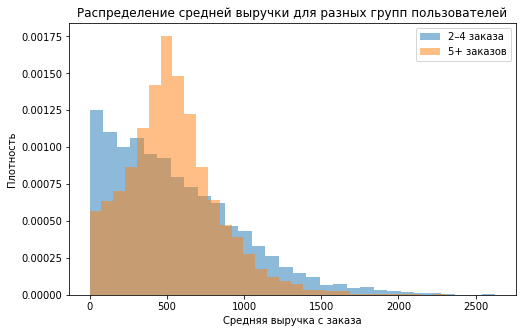

In [49]:
plt.figure(figsize=(8,5))

plt.hist(group_2_4['avg_revenue'], bins=30, alpha=0.5, density=True, label='2–4 заказа')
plt.hist(group_5_plus['avg_revenue'], bins=30, alpha=0.5, density=True, label='5+ заказов')

plt.xlabel('Средняя выручка с заказа')
plt.ylabel('Плотность')
plt.title('Распределение средней выручки для разных групп пользователей')
plt.legend()

plt.show()

Распределение средней выруччки для пользовалетей с 2-4 заказами и 5+ расположена в диапозонее 300-700. У пользовалетекй с 5+ чаще встречаются значения 500-800, это значито, что активные пользователи в среднем делают более дороги заказы. 

---

**Задача 4.2.3.** Проанализируйте влияние среднего количества билетов в заказе на вероятность повторной покупки.

- Изучите распределение пользователей по среднему количеству билетов в заказе (`avg_tickets_count`) и опишите основные наблюдения.
- Разделите пользователей на несколько сегментов по среднему количеству билетов в заказе:
    - от 1 до 2 билетов;
    - от 2 до 3 билетов;
    - от 3 до 5 билетов;
    - от 5 и более билетов.
- Для каждого сегмента подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы.
- Ответьте на вопросы:
    - Как распределены пользователи по сегментам — равномерно или сконцентрировано?
    - Есть ли сегменты с аномально высокой или низкой долей повторных покупок?

---

In [ ]:
user_profile['avg_tickets'].describe()

In [50]:
def tickets_segment(x):
    if x < 2:
        return '1-2 билета'
    elif x < 3:
        return '2-3 билета'
    elif x < 5:
        return '3-5 билетов'
    else:
        return '5+ билетов'

user_profile['tickets_segment'] = user_profile['avg_tickets'].apply(tickets_segment)

tickets_analysis = user_profile.groupby('tickets_segment').agg(
    users=('user_id','count'),
    return_rate=('is_two','mean')
).reset_index()

tickets_analysis

,tickets_segment,users,return_rate
0,1-2 билета,2410,0.512448
1,2-3 билета,9695,0.741310
2,3-5 билетов,9072,0.543320
3,5+ билетов,661,0.187595


---

#### 4.3. Исследование временных характеристик первого заказа и их влияния на повторные покупки

Изучите временные параметры, связанные с первым заказом пользователей:

- день недели первой покупки;
- время с момента первой покупки — лайфтайм;
- средний интервал между покупками пользователей с повторными заказами.

---

**Задача 4.3.1.** Проанализируйте, как день недели, в которой была совершена первая покупка, влияет на поведение пользователей.

- По данным даты первого заказа выделите день недели.
- Для каждого дня недели подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы. Результаты визуализируйте.
- Ответьте на вопрос: влияет ли день недели, в которую совершена первая покупка, на вероятность возврата клиента?

---


In [52]:
user_profile['first_day'] = user_profile['first_order_dt'].dt.day_name()

In [53]:
weekday_analysis = user_profile.groupby('first_day').agg(
    users=('user_id','count'),
    return_rate=('is_two','mean')
).reset_index()

weekday_analysis

,first_day,users,return_rate
0,Friday,3258,0.597913
1,Monday,2931,0.631525
2,Saturday,3456,0.642072
3,Sunday,2810,0.605338
4,Thursday,3119,0.595383
5,Tuesday,3188,0.620452
6,Wednesday,3076,0.624512


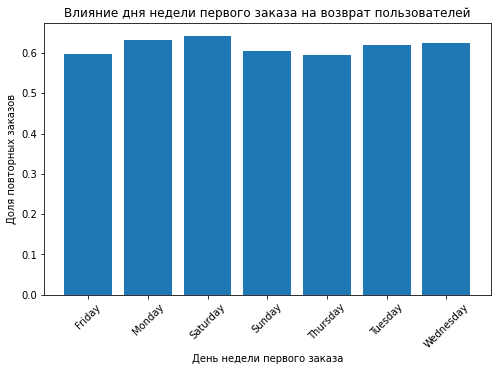

In [54]:
plt.figure(figsize=(8,5))

plt.bar(weekday_analysis['first_day'], weekday_analysis['return_rate'])

plt.xlabel('День недели первого заказа')
plt.ylabel('Доля повторных заказов')
plt.title('Влияние дня недели первого заказа на возврат пользователей')

plt.xticks(rotation=45)
plt.show()

День недели влияет, но не сильно, в субботу возвращаются примерно на 0.02 процента больше, чем в другие дни

---

**Задача 4.3.2.** Изучите, как средний интервал между заказами влияет на удержание клиентов.

- Рассчитайте среднее время между заказами для двух групп пользователей:
    - совершившие 2–4 заказа;
    - совершившие 5 и более заказов.
- Исследуйте, как средний интервал между заказами влияет на вероятность повторного заказа, и сделайте выводы.

---


In [55]:
group_2_4 = user_profile[(user_profile['orders_count'] >= 2) & (user_profile['orders_count'] <= 4)]
group_5_plus = user_profile[user_profile['orders_count'] >= 5]
print('Средний интервал (2–4 заказа):', group_2_4['avg_days_between'].mean())
print('Средний интервал (5+ заказов):', group_5_plus['avg_days_between'].mean())

Средний интервал (2–4 заказа): 21.32867842643147
Средний интервал (5+ заказов): 9.58448832212134


In [56]:
group_2_4['avg_days_between'].describe()

count    7143.000000
mean       21.328678
std        28.485070
min         0.000000
25%         0.000000
50%         9.000000
75%        34.000000
max       148.000000
Name: avg_days_between, dtype: float64

In [57]:
group_5_plus['avg_days_between'].describe()

count    6332.000000
mean        9.584488
std         7.861242
min         0.000000
25%         3.431006
50%         7.789474
75%        13.783333
max        37.500000
Name: avg_days_between, dtype: float64

У 5+ заказов средний интервал у заказов 9.5 дней, а у 2-4 заказов 21 день

---

#### 4.4. Корреляционный анализ количества покупок и признаков пользователя

Изучите, какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок. Для этого используйте универсальный коэффициент корреляции `phi_k`, который позволяет анализировать как числовые, так и категориальные признаки.

---

**Задача 4.4.1:** Проведите корреляционный анализ:
- Рассчитайте коэффициент корреляции `phi_k` между признаками профиля пользователя и числом заказов (`total_orders`). При необходимости используйте параметр `interval_cols` для определения интервальных данных.
- Проанализируйте полученные результаты. Если полученные значения будут близки к нулю, проверьте разброс данных в `total_orders`. Такое возможно, когда в данных преобладает одно значение: в таком случае корреляционный анализ может показать отсутствие связей. Чтобы этого избежать, выделите сегменты пользователей по полю `total_orders`, а затем повторите корреляционный анализ. Выделите такие сегменты:
    - 1 заказ;
    - от 2 до 4 заказов;
    - от 5 и выше.
- Визуализируйте результат корреляции с помощью тепловой карты.
- Ответьте на вопрос: какие признаки наиболее связаны с количеством заказов?

---

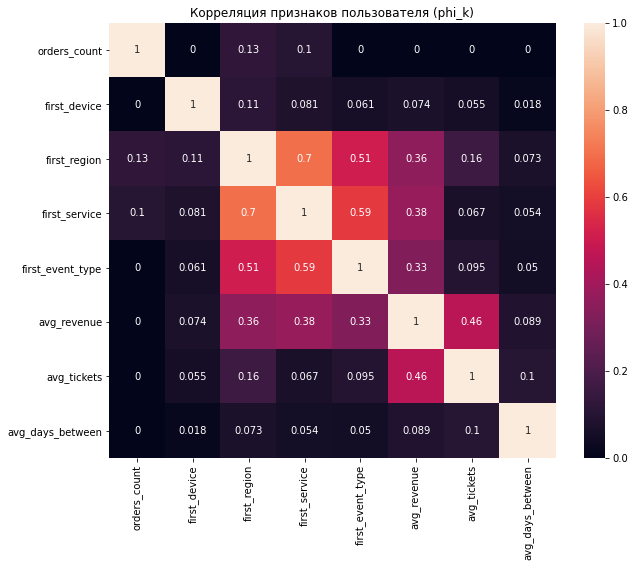

In [58]:
corr_df = user_profile[[
    'orders_count',
    'first_device',
    'first_region',
    'first_service',
    'first_event_type',
    'avg_revenue',
    'avg_tickets',
    'avg_days_between'
]]
phik_matrix = corr_df.phik_matrix(
    interval_cols=['orders_count','avg_revenue','avg_tickets','avg_days_between']
)
plt.figure(figsize=(10,8))

sns.heatmap(phik_matrix, annot=True)

plt.title('Корреляция признаков пользователя (phi_k)')
plt.show()

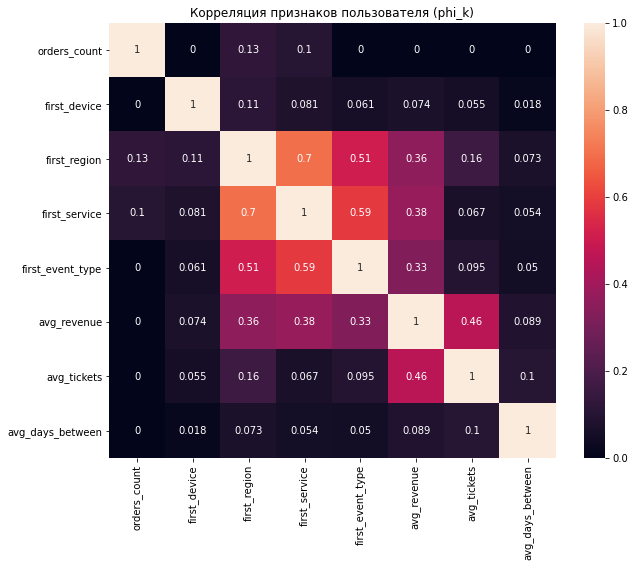

In [59]:
plt.figure(figsize=(10,8))

sns.heatmap(phik_matrix, annot=True)

plt.title('Корреляция признаков пользователя (phi_k)')
plt.show()

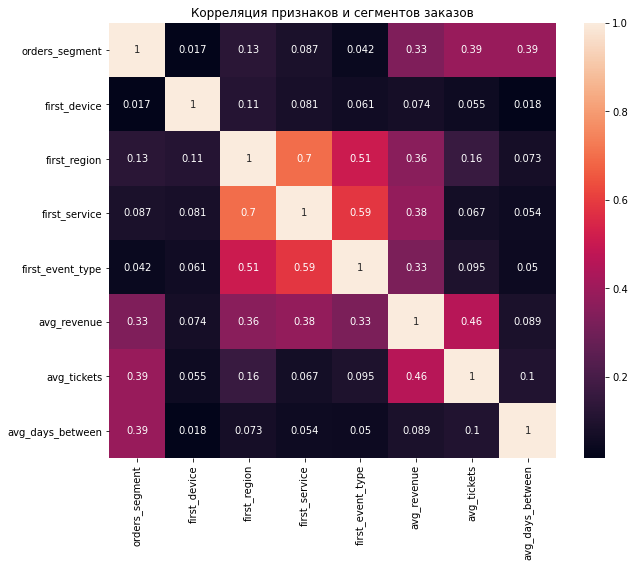

In [60]:
def order_segment(x):
    if x == 1:
        return '1 заказ'
    elif x <= 4:
        return '2-4 заказа'
    else:
        return '5+ заказов'

user_profile['orders_segment'] = user_profile['orders_count'].apply(order_segment)

corr_df2 = user_profile[[
    'orders_segment',
    'first_device',
    'first_region',
    'first_service',
    'first_event_type',
    'avg_revenue',
    'avg_tickets',
    'avg_days_between'
]]

phik_matrix2 = corr_df2.phik_matrix(
    interval_cols=['avg_revenue','avg_tickets','avg_days_between']
)

plt.figure(figsize=(10,8))

sns.heatmap(phik_matrix2, annot=True)

plt.title('Корреляция признаков и сегментов заказов')
plt.show()

avg_revenue - 0.33, avg_tikets, avg_days_between - 0.39 наиболее сильная зависимость.Наиболее слабая зависимость first_service - 0.087,first_event_type - 0.042,first_device - 0.017

### 5. Общий вывод и рекомендации

В конце проекта напишите общий вывод и рекомендации: расскажите заказчику, на что нужно обратить внимание. В выводах кратко укажите:

- **Информацию о данных**, с которыми вы работали, и то, как они были подготовлены: например, расскажите о фильтрации данных, переводе тенге в рубли, фильтрации выбросов.
- **Основные результаты анализа.** Например, укажите:
    - Сколько пользователей в выборке? Как распределены пользователи по числу заказов? Какие ещё статистические показатели вы подсчитали важным во время изучения данных?
    - Какие признаки первого заказа связаны с возвратом пользователей?
    - Как связаны средняя выручка и количество билетов в заказе с вероятностью повторных покупок?
    - Какие временные характеристики влияют на удержание (день недели, интервалы между покупками)?
    - Какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок согласно результатам корреляционного анализа?
- Дополните выводы информацией, которая покажется вам важной и интересной. Следите за общим объёмом выводов — они должны быть компактными и ёмкими.

В конце предложите заказчику рекомендации о том, как именно действовать в его ситуации. Например, укажите, на какие сегменты пользователей стоит обратить внимание в первую очередь, а какие нуждаются в дополнительных маркетинговых усилиях.

Итоговый вывод по исследованию пользователей сервиса продажи билетов

Подготовка данных: в  ходе работы были проанализированы данные о заказах пользователей сервиса продажи билетов. Данные содержали информацию о заказах, пользователях, устройствах, регионах, типах мероприятий и финансовых показателях.

На этапе предобработки были выполнены следующие действия:выручка, представленная в тенге, была приведена к единой валюте - к рублям с использованием данных о курсе валют; проверены пропущенные значения - они присутствовали только в столбце days_since_prev, что соответствует логике данных; проведена проверка категориальных признаков и нормализация категорий;
изучено распределение числовых показателей; выявлены выбросы в показателе выручки (revenue_rub), после чего данные были отфильтрованы по 99-му перцентилю; на основе заказов был построен профиль пользователя, включающий характеристики первого заказа, финансовые показатели и поведенческие метрики.

Общая характеристика данных:
В исследовании было проанализировано 29.0611 пользователей.
Распределение пользователей по количеству заказов показало:большинство пользователей совершают 1-2 заказа;значительно меньше пользователей совершают 5 и более заказов.
Средние показатели:средняя выручка с заказа - около 550 рублей; среднее количество билетов в заказе - около 2,7.

Связь признаков первого заказа с возвратом пользователей:
Анализ показал, что признаки первого заказа оказывают слабое влияние на вероятность повторных покупок.
Такие параметры как:тип устройства,регион,билетный оператор,тип мероприятия не демонстрируют сильной зависимости с вероятностью возвращения пользователя.


Поведение пользователей и повторные покупки:
Средняя выручка: пользователи, совершающие большее количество заказов, в среднем имеют немного более высокую выручку с заказа. Однако распределения выручки для разных групп пользователей сильно пересекаются, поэтому влияние этого фактора умеренное.

Количество билетов:
Была выявлена зависимость между средним количеством билетов в заказе и вероятностью повторной покупки: пользователи, покупающие больше билетов, чаще возвращаются на платформу.Это может свидетельствовать о более высокой вовлечённости таких пользователей.

Временные характеристики:
Анализ временных факторов показал:день недели первой покупки практически не влияет на вероятность возврата пользователей; средний интервал между покупками связан с активностью пользователя: пользователи с большим количеством заказов совершают покупки чаще.

Корреляционный анализ:
С использованием коэффициента корреляции phi_k была изучена связь между характеристиками пользователя и количеством заказов.

Наиболее заметная связь наблюдается с: средним количеством билетов в заказе - 0.39, средним интервалом между покупками - 0.39, средней выручкой с заказа - 0.33. Характеристики первого заказа (устройство, регион, тип мероприятия) показали слабую связь с количеством заказов. Это указывает на то, что поведенческие характеристики пользователей важнее, чем параметры первого заказа.

Рекомендации для бизнеса:
На основе проведённого анализа можно предложить следующие рекомендации:Сфокусироваться на пользователях с более крупными заказами.Пользователи, покупающие больше билетов и совершающие более дорогие заказы, демонстрируют более высокую вероятность повторных покупок.Развивать стратегии удержания пользователей после первого заказа.Поскольку большинство пользователей совершают только один заказ, важно стимулировать их к повторной покупке — например, через персональные предложения, скидки или рекомендации мероприятий.Анализировать поведенческие паттерны пользователей.Интервал между покупками может использоваться для прогнозирования активности пользователей и настройки маркетинговых кампаний.Использовать данные профиля пользователя для построения модели удержания.Поведенческие показатели (частота покупок, средний чек, количество билетов) могут быть использованы в будущих моделях прогнозирования возврата пользователей.

### 6. Финализация проекта и публикация в Git

Когда вы закончите анализировать данные, оформите проект, а затем опубликуйте его.

Выполните следующие действия:

1. Создайте файл `.gitignore`. Добавьте в него все временные и чувствительные файлы, которые не должны попасть в репозиторий.
2. Сформируйте файл `requirements.txt`. Зафиксируйте все библиотеки, которые вы использовали в проекте.
3. Вынести все чувствительные данные (параметры подключения к базе) в `.env`файл.
4. Проверьте, что проект запускается и воспроизводим.
5. Загрузите проект в публичный репозиторий — например, на GitHub. Убедитесь, что все нужные файлы находятся в репозитории, исключая те, что в `.gitignore`. Ссылка на репозиторий понадобится для отправки проекта на проверку. Вставьте её в шаблон проекта в тетрадке Jupyter Notebook перед отправкой проекта на ревью.

**Вставьте ссылку на проект в этой ячейке тетрадки перед отправкой проекта на ревью.**